# 00 · Start here — the data and how to run everything

*MecaNano · Machine Learning for Nanomechanics — companion to Tutorial 1*

> ⏱ **Runtime:** ~5 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu map · AFM grid · raw curves

### 🎯 What you'll learn
1. what a **nanoindentation map** is and what the datasets in this repo contain,
2. how to **run a notebook** cell by cell (no prior Python needed),
3. how the helper package `mecanano_ml` loads the data for you,
4. which notebook teaches which machine-learning method.

### 🧭 What you need to know first
- Nothing! This is the gentlest notebook. If you have never used Python or Jupyter, read the blue box just below.

> ### 🐍 New to Python or Jupyter? Read me first
>
> A **notebook** is a page made of *cells*. A **cell** is a small box that holds
> either text (like this one) or Python **code**.
>
> - **To run a code cell:** click it, then press **Shift + Enter**. The code runs
>   and any result appears just below it.
> - **Run cells top to bottom, in order.** Later cells use things created by
>   earlier ones, so if you skip around you may get an error.
> - The **kernel** is the little Python engine running your cells. If things get
>   confused, use the menu **Kernel → Restart & Run All** to start fresh.
> - You do **not** need to understand every line. Comments (text after a `#`)
>   explain the tricky parts; focus on the idea, not the syntax.
>
> That is genuinely all you need to follow this whole tutorial. 👍

## What is a nanoindentation map?

**Nanoindentation** pushes a tiny diamond tip into a material and records how far
it sinks under a known force — a *load–depth curve*. From that curve we compute two
numbers per point: the **hardness** *H* (resistance to being pressed in) and the
**elastic modulus** *E* (stiffness). A **high-speed map** simply repeats this on a
fine grid — tens of thousands of points — so *H* and *E* become images of the
material's surface. Because different **phases** (regions of different composition
or structure) have different *H* and *E*, these maps reveal the microstructure
without any labels — which is exactly what the machine-learning methods in this
repo learn to exploit.

### The notebooks at a glance
| # | Notebook | Method you'll meet |
|---|----------|--------------------|
| 01 | `features_and_pca` | features, standardisation, **PCA**, t‑SNE/UMAP |
| 01a | `linear_and_logistic_regression` | fit a line; predict a class (the gentlest models) |
| 02 | `clustering_phases` | **k‑means, silhouette, GMM, HDBSCAN** → a phase map |
| 02a | `knn_classifier` | classify by **nearest neighbours** |
| 03 | `supervised_trees_rf_shap` | **decision tree → random forest → boosting**, SMOTE, **SHAP** |
| 03a | `evaluating_models` | cross‑validation, **precision/recall, ROC** — trust a model |
| 04 | `curve_as_image_cnn` | **GASF** (curve→image) + a small **CNN** |
| 04a | `1d_cnn_on_curves` | a **1-D CNN** on the raw curve (keeps magnitude) |
| 05 | `autoencoder_latent_space` | **autoencoder** and its **latent space** |
| 06 | `correlative_registration` | aligning two maps, agreement & confusion |
| 07 | `substrate_layer_deconvolution` | **coating vs substrate** deconvolution (physics + ML) on a CrN–Cr bilayer |
| 08 | `single_vs_depth_resolved` | **single-depth vs depth-resolved** phase mapping — one depth vs the whole curve (Al–Cu) |
| 10–13 | refreshed classics | MNIST CNN · pop‑in detection · curve fitting · YOLO (optional) |

Open them roughly in this order. Each is self‑contained and runs in **under two
minutes** on an ordinary laptop — no GPU, no big downloads.

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


## 1 · A high-speed nanoindentation map (Al–Cu eutectic)

Our main dataset is a map of an **Al–Cu eutectic** alloy: a soft aluminium-rich
matrix laced with a hard Al₂Cu intermetallic. Let's load it and look at it.

> 🧠 **indent** — one measurement point — a single push of the tip, giving one hardness and one modulus value. The map below has 40,000 of them.

> ✅ **When you run the next cell, you should see:** a table summary: ~40,000 rows (indents) and the columns `H`, `E`, `HE`, `X`, `Y`, with typical hardness a few GPa.

In [2]:
# Load the 2-µm-spacing Al–Cu map as a table (one row per indent).
df = mm.load_map("alcu_2um")
# {len(df):,} inserts the row count with thousands separators.
print(f"{len(df):,} indents · columns: {list(df.columns)}")
# .describe() gives count/mean/std/min/max per column; .round(2) keeps it readable.
df[["H", "E", "HE"]].describe().round(2)

40,000 indents · columns: ['Index', 'Load', 'Depth', 'H', 'E', 'HE', 'X', 'Y', 'Z Position']


,H,E,HE
count,40000.00,40000.00,40000.00
mean,3.98,88.45,0.04
std,1.71,14.04,0.01
min,0.22,12.97,0.01
25%,2.50,78.01,0.03
50%,4.43,89.92,0.05
75%,5.26,98.65,0.05
max,9.28,161.98,0.15


> 🧠 **H, E and H/E** — `H` = hardness in GPa, `E` = elastic modulus in GPa, and
> `HE` = their ratio `H/E` (unitless). `H/E` is handy because it often separates
> phases even when *H* alone does not.

> ✅ **When you run the next cell, you should see:** two side-by-side images. The left (hardness) and right (modulus) both show the same two-phase pattern — a network of hard/stiff material in a softer/less-stiff background.

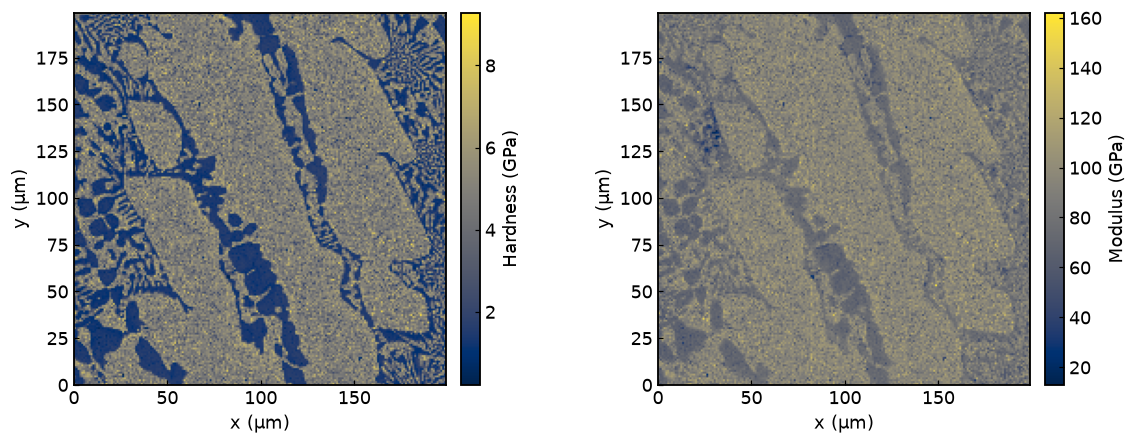

In [3]:
# Draw the hardness and modulus maps side by side.
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))          # one row, two panels
for a, v, lab in zip(ax, ["H", "E"], ["Hardness (GPa)", "Modulus (GPa)"]):
    g, ext = mm.map_to_grid(df, v)                       # reshape column -> 2-D image
    mm.plot_map(g, ext, ax=a, label=lab)                 # helper: image + colour bar
fig.tight_layout()

*🖼 **Figure.** Two views of the *same* area. Bright veins are the hard, stiff Al₂Cu intermetallic; the dark background is the soft Al matrix. The eye already sees two phases — the rest of the tutorial makes that judgement quantitative and automatic.*

A quick histogram makes the "two phases" idea concrete.

> 🧠 **histogram** — a bar chart of how often each value occurs. Two humps (bimodal) means the values cluster around two typical levels.

> ✅ **When you run the next cell, you should see:** a histogram of hardness with **two humps** — a low-hardness peak (matrix) and a high-hardness peak (intermetallic).

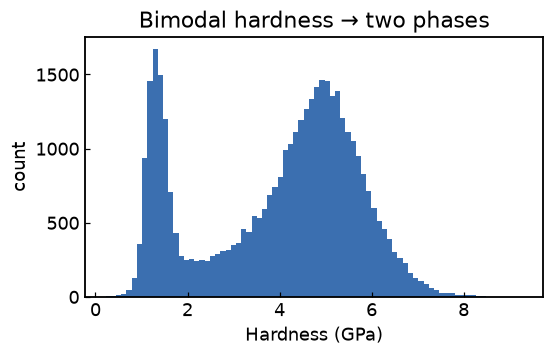

In [4]:
# A histogram of hardness: how many indents fall in each hardness bin.
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.hist(df["H"], bins=80, color="#3b6fb0")               # 80 bins across the H range
ax.set_xlabel("Hardness (GPa)"); ax.set_ylabel("count")
ax.set_title("Bimodal hardness → two phases"); fig.tight_layout()

*🖼 **Figure.** Two peaks = two typical hardness levels = two phases. Every clustering/classification method later in the tutorial is, at heart, a principled way to split this histogram.*

## 2 · A small, fast grid (AFM-collocated)

When you just want something that runs in **seconds**, use the AFM grid: ~800
indents that carry the same scalars **and** the full depth-resolved curves. Most
of the deep-learning notebooks use it because it is quick.

> ✅ **When you run the next cell, you should see:** the list of arrays in the grid, the number of indents (~800), the depth axis of the curves, and its raw **hardness and modulus maps** side by side.

arrays: ['X', 'Y', 'H', 'E', 'HE', 'depth_nm', 'H_curve', 'E_curve', 'load_mN']
6554 indents · curve depth axis: 5–103 nm (56 pts)


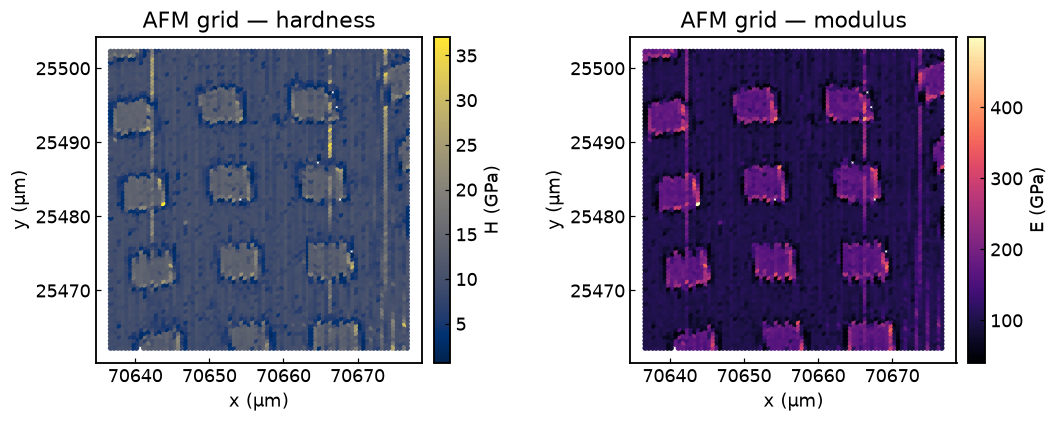

In [5]:
# Load the small AFM grid. It returns a dict of NumPy arrays.
afm = mm.load_afm_grid()
print("arrays:", list(afm.keys()))
# Each indent also has a full hardness-vs-depth curve on a common depth axis (its length is printed below).
print(f"{afm['H'].size} indents · curve depth axis: "
      f"{afm['depth_nm'][0]:.0f}–{afm['depth_nm'][-1]:.0f} nm ({afm['depth_nm'].size} pts)")

# The AFM grid is an irregular set of points, so we scatter each indent at its (x, y)
# position — coloured by hardness, then by modulus: the raw H and E property maps.
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
mm.scatter_xy(afm["X"], afm["Y"], afm["H"], ax=ax[0], cmap="cividis", s=14, label="H (GPa)")
ax[0].set_title("AFM grid — hardness")
mm.scatter_xy(afm["X"], afm["Y"], afm["E"], ax=ax[1], cmap="magma", s=14, label="E (GPa)")
ax[1].set_title("AFM grid — modulus")
fig.tight_layout()

*🖼 **Figure.** The AFM grid's raw hardness and modulus maps. Like the Al–Cu maps above, these are the raw data — one property value per (x, y) point. The grid is deliberately tiny so the deep-learning notebooks still finish in seconds.*

## 3 · Raw load–depth curves

The deep-learning and pop-in notebooks work from the **whole curve**, not a single
number. Here are a few raw ones.

> ✅ **When you run the next cell, you should see:** a handful of load–depth curves — load (mN) rising as the tip presses deeper (nm). They share a shape but differ in scale.

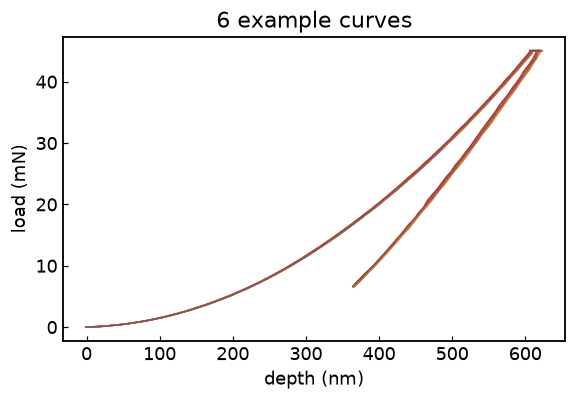

In [6]:
# Load 6 raw load–depth curves; each is a pair (depth in nm, load in mN).
curves = mm.load_curves(6)
fig, ax = plt.subplots(figsize=(5.4, 3.8))
for d, p in curves:                                      # d = depth, p = load
    ax.plot(d, p, lw=1)
ax.set_xlabel("depth (nm)"); ax.set_ylabel("load (mN)")
ax.set_title(f"{len(curves)} example curves"); fig.tight_layout()

*🖼 **Figure.** Each curve is one indent's full mechanical fingerprint. Notebooks 04, 05 and 11–12 learn directly from these shapes.*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert len(df) > 30000, "the Al–Cu map should have ~40,000 indents"
assert afm["H"].size > 500, "the AFM grid should have several hundred indents"
assert len(curves) == 6, "we asked for 6 example curves"
print("self-check passed ✓ — the datasets loaded")

self-check passed ✓ — the datasets loaded


## ✅ Recap
- A **nanoindentation map** is one hardness *H* and modulus *E* per grid point; the Al–Cu map is clearly **two-phase**.
- You load everything through one helper: `import mecanano_ml as mm`, then `mm.load_map(...)`, `mm.load_afm_grid()`, `mm.load_curves(...)`.
- Run cells **top to bottom with Shift + Enter**; each notebook is short and CPU-only.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. In the map cell, change `"alcu_2um"` to `"duplex_1um"` and re-run — you are now looking at a duplex steel. How many phases do you see?
2. Call `mm.list_maps()` in a new cell to print every dataset name you can load.
3. In the curves cell, change `mm.load_curves(6)` to `mm.load_curves(20)` — do the curves still overlap in shape?

## 🩹 Common errors & fixes
- **`ModuleNotFoundError: mecanano_ml`** → you skipped the set-up cell. Run it first (Shift + Enter), then re-run.
- **A plot doesn't appear** → make sure you ran the cell (a `[*]` means it is still running; a number like `[3]` means it finished).
- **Something looks stuck or wrong after editing** → use **Kernel → Restart & Run All**.

---
**Next:** open **`01_features_and_pca.ipynb`** — turn these curves into features and find the structure with PCA.